In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.2
)


In [2]:
# State Definition

from langgraph.graph import MessagesState

class STMState(MessagesState):
    summary: str

In [3]:
MAX_TOKENS = 200
MAX_MESSAGES_BEFORE_SUMMARY = 6


In [4]:
# Chat Node
from langchain_core.messages import SystemMessage
from langchain_core.messages.utils import (
    trim_messages,
    count_tokens_approximately
)

def chat_node(state: STMState):
    messages = []

    # Inject summary as system context
    if state.get("summary"):
        messages.append(
            SystemMessage(
                content=f"Conversation summary:\n{state['summary']}"
            )
        )

    # Trim messages for token safety
    trimmed = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    messages.extend(trimmed)

    response = llm.invoke(messages)

    return {"messages": [response]}


In [5]:
# Summarization Node
from langchain_core.messages import HumanMessage, RemoveMessage

def summarize_node(state: STMState):
    existing_summary = state.get("summary", "")

    prompt = (
        f"Existing summary:\n{existing_summary}\n\n"
        "Update the summary using the conversation above."
        if existing_summary
        else "Summarize the conversation above."
    )

    summary_messages = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    summary_response = llm.invoke(summary_messages)

    # Keep last 2 messages verbatim
    messages_to_remove = state["messages"][:-2]

    return {
        "summary": summary_response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_remove],
    }


In [6]:
# Summarization Condition
def should_summarize(state: STMState):
    return len(state["messages"]) > MAX_MESSAGES_BEFORE_SUMMARY


In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(STMState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_node)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: END
    }
)

builder.add_edge("summarize", END)


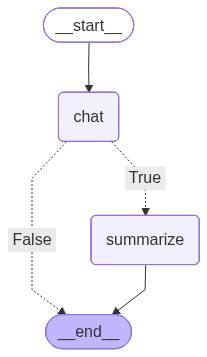

In [8]:
# Compile with Checkpointer
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

workflow = builder.compile(checkpointer=checkpointer)
workflow


In [9]:
config = {"configurable": {"thread_id": "user-1"}}

def run_turn(text: str):
    return workflow.invoke(
        {"messages": [HumanMessage(content=text)]},
        config=config
    )

In [10]:
run_turn("Hi, my name is Hemant")
run_turn("I am learning Agentic AI")
run_turn("I prefer Python")
run_turn("Explain LangGraph")
run_turn("What is my name?")


{'messages': [HumanMessage(content='Explain LangGraph', additional_kwargs={}, response_metadata={}, id='6404ad31-532c-405f-81d0-e54f52e16679'),
  AIMessage(content="LangGraph is an open-source, Python-based framework for building and training neural networks. It's designed to be highly efficient, flexible, and scalable, making it suitable for a wide range of applications, including computer vision, natural language processing, and reinforcement learning.\n\nKey Features:\n\n1. **Modular Architecture**: LangGraph is built around a modular architecture, allowing users to easily add or remove components as needed.\n2. **Python API**: The framework provides a Python API that makes it easy to define and train neural networks using standard Python syntax.\n3. **Dynamic Computation Graph**: LangGraph uses a dynamic computation graph, which allows for more efficient computation and reduced memory usage compared to traditional static graphs.\n4. **AutoML Capabilities**: LangGraph includes autoM

In [11]:
snap = workflow.get_state(config)
vals = snap.values

print("\n--- STM STATE ---")
print("SUMMARY:\n", vals.get("summary", ""))
print("\nMESSAGES:")
for m in vals.get("messages", []):
    print("-", type(m).__name__, ":", m.content)



--- STM STATE ---
SUMMARY:
 Here's a summary of our conversation:

* You introduced yourself as Hemant and mentioned that you're learning about Agentic AI.
* I asked if you had any specific topics in mind, and you mentioned that you prefer Python.
* I provided some resources and recommendations for learning about Agentic AI using Python, including libraries like Gym, PyTorch, and TensorFlow, as well as books and online courses.
* You specifically asked me to explain LangGraph, which is an open-source framework for building and training neural networks in Python. I highlighted its key features, advantages, and use cases, including its modular architecture, dynamic computation graph, autoML capabilities, and support for multiple backends.

I hope that summarizes our conversation! Let me know if you have any further questions or topics you'd like to discuss.

MESSAGES:
- HumanMessage : Explain LangGraph
- AIMessage : LangGraph is an open-source, Python-based framework for building and tr